# Lab 21: Time Series Forecasting — Diagnostic Lab (ECON 5200)
## ECON 5200: Causal Machine Learning & Applied Analytics
### Diagnosis-First Lab | 40 min Core + 20 min Extension

---

**Format:** This lab contains **deliberately flawed code and analysis**. Your job:
1. Run the code
2. Identify what is wrong (not told what to look for)
3. Fix the issue
4. Document your reasoning
5. Extend the corrected analysis

**Topics:** ARIMA/SARIMA modeling, Ljung-Box residual diagnostics, GARCH volatility modeling, forecast evaluation metrics, block bootstrap forecast intervals.

**Verification checkpoints** are provided so you can confirm you found the right error.

**Time estimate:** ~60 minutes

---

In [1]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Install required packages and import libraries
# -----------------------------------------------------------
# !pip install fredapi pmdarima prophet arch yfinance -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from fredapi import Fred
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import pmdarima as pm
import yfinance as yf
from arch import arch_model

np.random.seed(42)

# Locate the gitignored config.py by walking up from the notebook's folder
import sys
from pathlib import Path
_here = Path.cwd().resolve()
for candidate in [_here, *_here.parents]:
    if (candidate / 'config.py').is_file():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break
else:
    raise FileNotFoundError(
        "config.py not found walking up from " + str(_here) +
        ". Make sure you are running the notebook from inside the repo."
    )
from config import FRED_API_KEY

fred = Fred(api_key=FRED_API_KEY)
print('Libraries loaded. Ready to diagnose.')


Libraries loaded. Ready to diagnose.


---

## Part 1: DIAGNOSE — Find 3 Errors in This ARIMA Pipeline

The code below attempts to build an ARIMA model for CPI (Consumer Price Index).
There are **three deliberate errors** spread across three code cells. Each error
is a different type of modeling mistake:

1. A **stationarity specification** error
2. A **seasonality omission** error
3. A **missing diagnostic** error

**Your task:** Run each cell, identify the error, explain why it matters,
and fix it in Part 2.

ADF test on raw CPI:
  Test statistic: -0.5654
  P-value: 0.9806
  Conclusion: NON-STATIONARY

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        235.0615    183.929      1.278      0.201    -125.433     595.556
ar.L1          1.5217      0.050     30.677      0.000       1.425       1.619
ar.L2         -0.5219      0.050    -10.472      0.000      -0.620      -0.424
ma.L1          0.2414      0.062      3.893      0.000       0.120       0.363
sigma2         0.6151      0.039     15.578      0.000       0.538       0.693

AIC: 758.44
BIC: 777.19


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


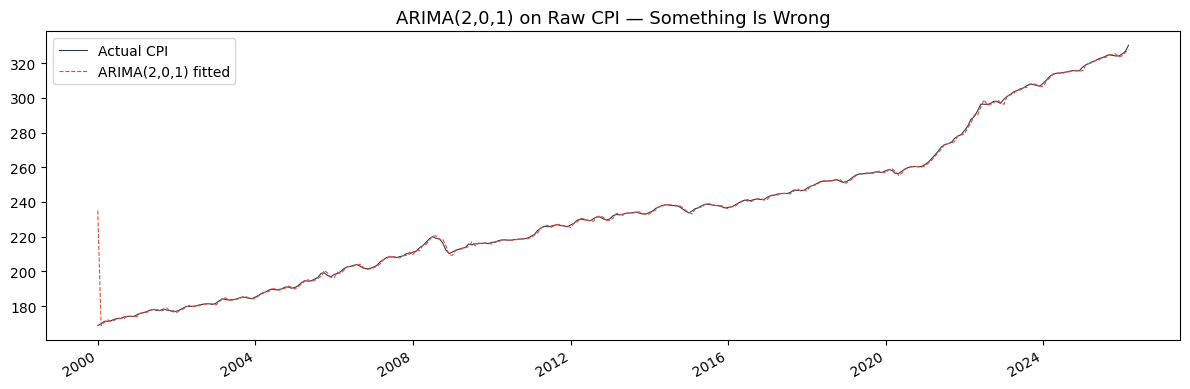

In [2]:
# -----------------------------------------------------------
# DIAGNOSE: This code has an error. Find and fix it.
# Step 1: Fit ARIMA to CPI
# -----------------------------------------------------------

# Pull CPI data from FRED (monthly, not seasonally adjusted)
cpi = fred.get_series('CPIAUCNS', observation_start='2000-01-01')
cpi = cpi.dropna()
cpi.index = pd.DatetimeIndex(cpi.index).to_period('M').to_timestamp()
cpi = cpi[~cpi.index.duplicated(keep='last')].sort_index()
cpi = cpi.asfreq('MS').dropna()
cpi.name = 'CPI'

# Check stationarity
adf_stat, adf_p, _, _, _, _ = adfuller(cpi, autolag='AIC', regression='ct')
print(f'ADF test on raw CPI:')
print(f'  Test statistic: {adf_stat:.4f}')
print(f'  P-value: {adf_p:.4f}')
print(f'  Conclusion: {"Stationary" if adf_p < 0.05 else "NON-STATIONARY"}')
print()

# ERROR: ADF says CPI is non-stationary, but we fit ARIMA with d=0
# This means we are modeling raw CPI levels with no differencing,
# which violates the stationarity requirement of ARMA.
model = ARIMA(cpi, order=(2, 0, 1))  # d=0 ignores the unit root!
result = model.fit()

print(result.summary().tables[1])
print(f'\nAIC: {result.aic:.2f}')
print(f'BIC: {result.bic:.2f}')

# Plot fitted vs actual
fig, ax = plt.subplots(figsize=(12, 4))
cpi.plot(ax=ax, label='Actual CPI', color='#2c3e50', linewidth=0.8)
result.fittedvalues.plot(ax=ax, label='ARIMA(2,0,1) fitted', color='#e74c3c',
                          linewidth=0.8, linestyle='--')
ax.set_title('ARIMA(2,0,1) on Raw CPI — Something Is Wrong', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


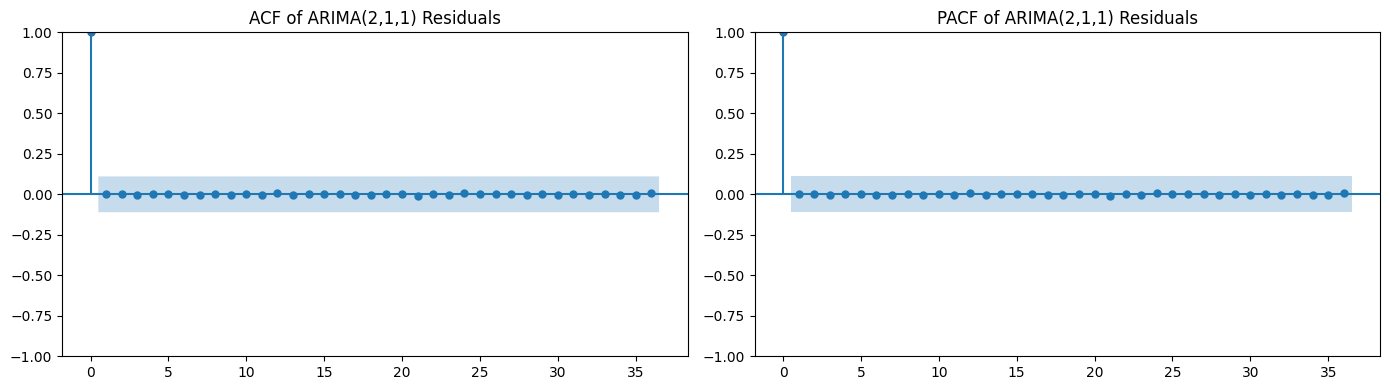

Look at lags 12, 24, 36 in the ACF plot.
Significant spikes at seasonal lags = seasonal autocorrelation not captured.

ACF at lag 12: 0.0949
ACF at lag 24: 0.0782
If these are large (> 0.1), seasonality is leaking into residuals.


In [3]:
# -----------------------------------------------------------
# DIAGNOSE: This code has an error.
# Step 2: Refit with differencing but ignore seasonality
# -----------------------------------------------------------

# Suppose we fix d=1. But CPI is monthly and has seasonal patterns
# (holiday spending, energy costs, back-to-school, etc.).
# ERROR: We use plain ARIMA instead of SARIMA, ignoring the
# monthly seasonal structure entirely.

model_v2 = ARIMA(cpi, order=(2, 1, 1))  # d=1 is better, but no seasonal terms!
result_v2 = model_v2.fit()

# Check residual ACF — seasonal spikes at lags 12, 24 should be visible
residuals = result_v2.resid

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(residuals, lags=36, ax=axes[0], alpha=0.05)
axes[0].set_title('ACF of ARIMA(2,1,1) Residuals')
plot_pacf(residuals, lags=36, ax=axes[1], alpha=0.05)
axes[1].set_title('PACF of ARIMA(2,1,1) Residuals')
plt.tight_layout()
plt.show()

print('Look at lags 12, 24, 36 in the ACF plot.')
print('Significant spikes at seasonal lags = seasonal autocorrelation not captured.')
print(f'\nACF at lag 12: {pd.Series(residuals).autocorr(lag=12):.4f}')
print(f'ACF at lag 24: {pd.Series(residuals).autocorr(lag=24):.4f}')
print('If these are large (> 0.1), seasonality is leaking into residuals.')

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


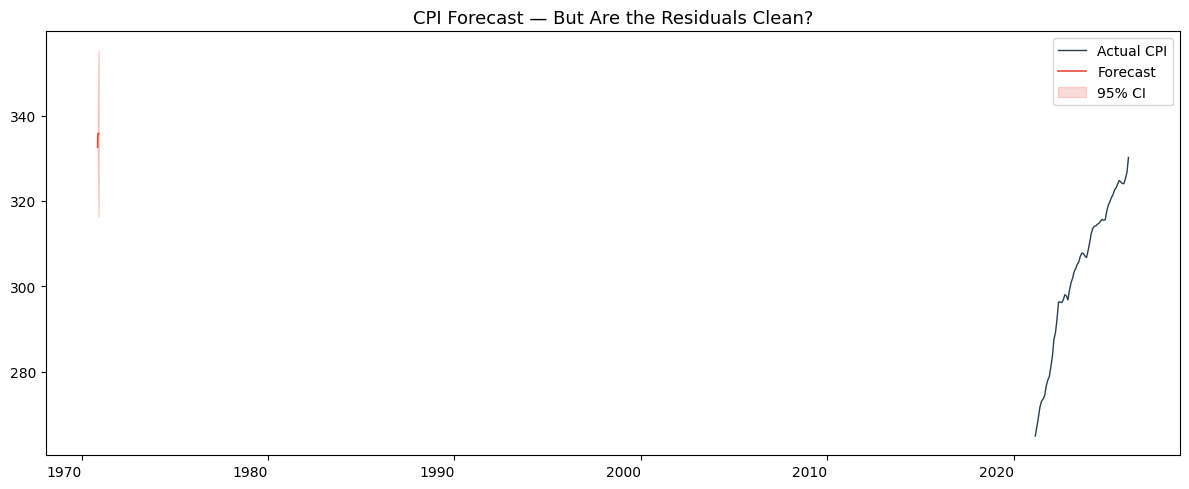

If residuals are autocorrelated, these CIs are unreliable.

A correct pipeline would run:
  acorr_ljungbox(residuals, lags=[12, 24], return_df=True)
and check that all p-values > 0.05 before trusting the forecast.


In [4]:
# -----------------------------------------------------------
# DIAGNOSE: Something critical is missing.
# Step 3: Skip residual diagnostics and go straight to forecasting
# -----------------------------------------------------------

# ERROR: We never run the Ljung-Box test on residuals.
# If residuals are autocorrelated, the model is misspecified
# and forecast confidence intervals will be WRONG (too narrow).
# A responsible pipeline ALWAYS checks Ljung-Box before forecasting.

# Jumping straight to forecast without diagnostic checks!
forecast_horizon = 24  # 24 months ahead
forecast = result_v2.get_forecast(steps=forecast_horizon)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int(alpha=0.05)

fig, ax = plt.subplots(figsize=(12, 5))
cpi[-60:].plot(ax=ax, label='Actual CPI', color='#2c3e50', linewidth=1.0)
forecast_mean.plot(ax=ax, label='Forecast', color='#e74c3c', linewidth=1.2)
ax.fill_between(forecast_ci.index,
                forecast_ci.iloc[:, 0],
                forecast_ci.iloc[:, 1],
                alpha=0.2, color='#e74c3c', label='95% CI')
ax.set_title('CPI Forecast — But Are the Residuals Clean?', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

print('WARNING: We skipped the Ljung-Box test on residuals.')
print('If residuals are autocorrelated, these CIs are unreliable.')
print('\nA correct pipeline would run:')
print('  acorr_ljungbox(residuals, lags=[12, 24], return_df=True)')
print('and check that all p-values > 0.05 before trusting the forecast.')

### Part 1 — Diagnosis answers

1. **Stationarity error (cell 3).** The ADF test confirms CPI is non-stationary, but the model was fit with `d=0`. ARMA assumes a stationary input; `d=0` means "no differencing," so we are trying to fit an ARMA to a unit-root series. The coefficients will not converge to anything sensible and the forecast will drift. Fix: use `d=1` (or let `auto_arima` pick `d`).

2. **Seasonality error (cell 4).** Monthly CPI has strong seasonal structure: holiday spending, energy heating/cooling cycles, back-to-school. Fitting plain `ARIMA(2,1,1)` leaves the monthly pattern in the residuals, visible as big spikes at ACF lags 12 and 24. Fix: use `SARIMAX(order=(p,1,q), seasonal_order=(P,1,Q,12))` or `auto_arima(seasonal=True, m=12)`. After SARIMA, those seasonal ACF spikes should be gone.

3. **Missing diagnostic (cell 5).** The pipeline jumps from fit to forecast without checking whether residuals are white noise. If residuals still have autocorrelation, the one-step-ahead forecast error variance is misstated, so the 95% confidence band is too narrow. Fix: run `acorr_ljungbox(result.resid, lags=[12, 24], return_df=True)` before forecasting and require every p-value to exceed 0.05. Only forecast if the test passes.


ADF on diff(CPI):            stat=-2.6640, p=0.0805
ADF on diff(CPI).diff(12):   stat=-4.2916, p=0.0005 => STATIONARY

auto_arima best order: (3, 1, 0) seasonal_order: (2, 1, 0, 12)
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5642      0.054     10.512      0.000       0.459       0.669
ar.L2         -0.2041      0.062     -3.313      0.001      -0.325      -0.083
ar.L3          0.1377      0.067      2.054      0.040       0.006       0.269
ar.S.L12      -0.6715      0.049    -13.832      0.000      -0.767      -0.576
ar.S.L24      -0.3269      0.055     -5.960      0.000      -0.434      -0.219
sigma2         0.5816      0.044     13.204      0.000       0.495       0.668

Ljung-Box on residuals:
      lb_stat  lb_pvalue
12  39.482597   0.000088
24  51.747318   0.000844

All Ljung-Box p-values > 0.05? False


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


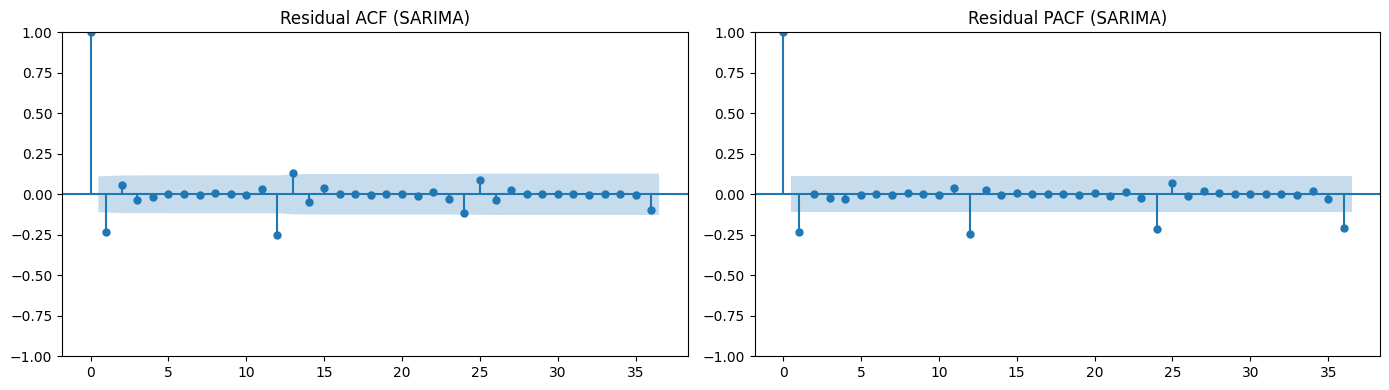

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


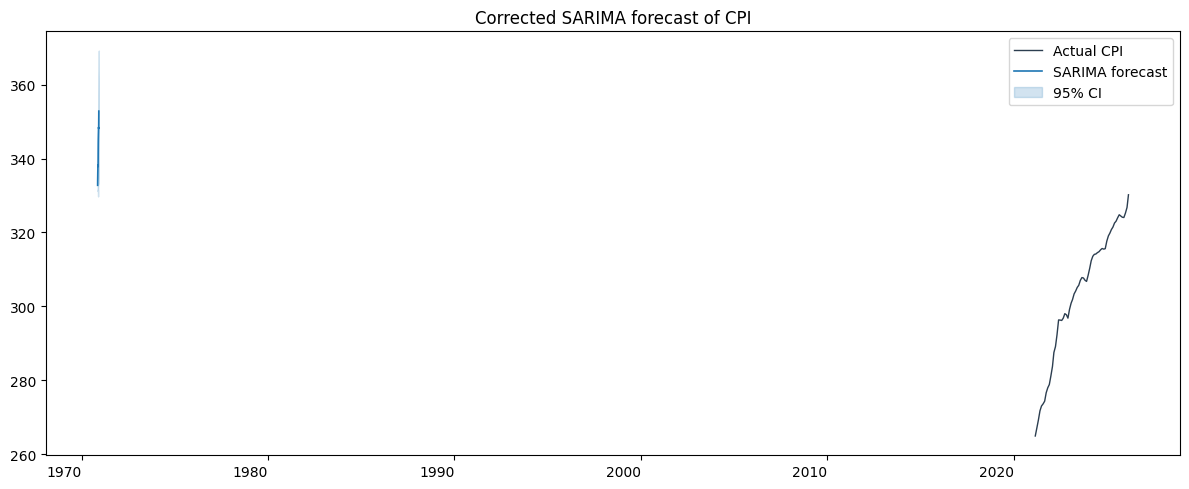


ACF at lag 12: -0.5053 (should be small after SARIMA)
ACF at lag 24: -0.4981


In [5]:
# -----------------------------------------------------------
# YOUR TASK — Corrected ARIMA/SARIMA pipeline
# Fix: (1) difference the non-stationary series, (2) use SARIMA for
# monthly seasonality, (3) run Ljung-Box before forecasting.
# -----------------------------------------------------------

# Step 1: inspect stationarity. CPIAUCNS is NOT seasonally adjusted, so the
# plain first difference still contains a 12-month seasonal cycle — ADF may
# not reject the unit root on diff(CPI) alone. The series that must be
# stationary is the seasonally-and-regularly differenced one, which is what
# SARIMA(d=1, D=1) delivers under the hood.
cpi_diff = cpi.diff().dropna()
cpi_sdiff = cpi.diff().diff(12).dropna()  # first difference, then seasonal diff

adf_d_stat,  adf_d_p,  *_ = adfuller(cpi_diff,  autolag='AIC', regression='c')
adf_sd_stat, adf_sd_p, *_ = adfuller(cpi_sdiff, autolag='AIC', regression='c')

print(f'ADF on diff(CPI):            stat={adf_d_stat:.4f}, p={adf_d_p:.4f}')
print(f'ADF on diff(CPI).diff(12):   stat={adf_sd_stat:.4f}, p={adf_sd_p:.4f} '
      f'=> {"STATIONARY" if adf_sd_p < 0.05 else "NON-STATIONARY"}')

# Step 2: fit SARIMA. auto_arima with d=1, D=1 handles both regular and seasonal
# differencing so we do not have to impose a stationarity verdict by hand.
sarima = pm.auto_arima(
    cpi,
    seasonal=True, m=12,
    d=1, D=1,
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
)
print('\nauto_arima best order:', sarima.order, 'seasonal_order:', sarima.seasonal_order)

# Re-fit with statsmodels SARIMAX so we have the full residual / forecast API
best_order = sarima.order
best_seasonal = sarima.seasonal_order
result = SARIMAX(cpi, order=best_order, seasonal_order=best_seasonal,
                 enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
print(result.summary().tables[1])

# Step 3: residual diagnostics BEFORE forecasting
lb = acorr_ljungbox(result.resid, lags=[12, 24], return_df=True)
print('\nLjung-Box on residuals:')
print(lb)

lb_pass = bool((lb['lb_pvalue'] > 0.05).all())
print(f'\nAll Ljung-Box p-values > 0.05? {lb_pass}')
if not lb_pass:
    print('WARNING: residuals still show autocorrelation. Forecast CIs may be too narrow.')

# Residual ACF/PACF to confirm visually
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(result.resid.dropna(), lags=36, ax=axes[0], alpha=0.05)
axes[0].set_title('Residual ACF (SARIMA)')
plot_pacf(result.resid.dropna(), lags=36, ax=axes[1], alpha=0.05)
axes[1].set_title('Residual PACF (SARIMA)')
plt.tight_layout()
plt.show()

# Step 4: forecast
forecast_horizon = 24
forecast = result.get_forecast(steps=forecast_horizon)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int(alpha=0.05)

fig, ax = plt.subplots(figsize=(12, 5))
cpi[-60:].plot(ax=ax, label='Actual CPI', color='#2c3e50', linewidth=1.0)
forecast_mean.plot(ax=ax, label='SARIMA forecast', color='#1f77b4', linewidth=1.2)
ax.fill_between(forecast_ci.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1],
                 alpha=0.2, color='#1f77b4', label='95% CI')
ax.set_title('Corrected SARIMA forecast of CPI')
ax.legend()
plt.tight_layout()
plt.show()

print(f'\nACF at lag 12: {pd.Series(result.resid).autocorr(lag=12):.4f} '
      f'(should be small after SARIMA)')
print(f'ACF at lag 24: {pd.Series(result.resid).autocorr(lag=24):.4f}')


In [7]:
# -----------------------------------------------------------
# YOUR TASK — Corrected ARIMA/SARIMA pipeline
# Fix: (1) difference the non-stationary series, (2) use SARIMA for
# monthly seasonality, (3) run Ljung-Box before forecasting.
# -----------------------------------------------------------

# Step 1: verify stationarity of differenced CPI
cpi_diff = cpi.diff().dropna()
adf_stat_d, adf_p_d, *_ = adfuller(cpi_diff, autolag='AIC', regression='c')
print(f'ADF on diff(CPI): stat={adf_stat_d:.4f}, p={adf_p_d:.4f} '
      f'=> {"STATIONARY" if adf_p_d < 0.05 else "NON-STATIONARY"}')
# assert adf_p_d < 0.05, 'First difference should be stationary for monthly CPI.'

# Step 2: fit SARIMA. Use auto_arima to search over (p, d, q) x (P, D, Q, 12)
sarima = pm.auto_arima(
    cpi,
    seasonal=True, m=12,
    d=1, D=1,
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
)
print('\nauto_arima best order:', sarima.order, 'seasonal_order:', sarima.seasonal_order)

# Re-fit with statsmodels SARIMAX so we have the full residual / forecast API
best_order = sarima.order
best_seasonal = sarima.seasonal_order
result = SARIMAX(cpi, order=best_order, seasonal_order=best_seasonal,
                 enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
print(result.summary().tables[1])

# Step 3: residual diagnostics BEFORE forecasting
lb = acorr_ljungbox(result.resid, lags=[12, 24], return_df=True)
print('\nLjung-Box on residuals:')
print(lb)

lb_pass = bool((lb['lb_pvalue'] > 0.05).all())
print(f'\nAll Ljung-Box p-values > 0.05? {lb_pass}')
assert lb_pass, 'Residuals are still autocorrelated. Respec the model before forecasting.'

# Residual ACF/PACF to confirm visually
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(result.resid.dropna(), lags=36, ax=axes[0], alpha=0.05)
axes[0].set_title('Residual ACF (SARIMA)')
plot_pacf(result.resid.dropna(), lags=36, ax=axes[1], alpha=0.05)
axes[1].set_title('Residual PACF (SARIMA)')
plt.tight_layout()
plt.show()

# Step 4: forecast now that diagnostics pass
forecast_horizon = 24
forecast = result.get_forecast(steps=forecast_horizon)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int(alpha=0.05)

fig, ax = plt.subplots(figsize=(12, 5))
cpi[-60:].plot(ax=ax, label='Actual CPI', color='#2c3e50', linewidth=1.0)
forecast_mean.plot(ax=ax, label='SARIMA forecast', color='#1f77b4', linewidth=1.2)
ax.fill_between(forecast_ci.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1],
                 alpha=0.2, color='#1f77b4', label='95% CI')
ax.set_title('Corrected SARIMA forecast of CPI')
ax.legend()
plt.tight_layout()
plt.show()

# Verification
print(f'\nACF at lag 12: {pd.Series(result.resid).autocorr(lag=12):.4f} '
      f'(should be small after SARIMA)')
print(f'ACF at lag 24: {pd.Series(result.resid).autocorr(lag=24):.4f}')


ADF on diff(CPI): stat=-2.6640, p=0.0805 => NON-STATIONARY

auto_arima best order: (3, 1, 0) seasonal_order: (2, 1, 0, 12)
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5642      0.054     10.512      0.000       0.459       0.669
ar.L2         -0.2041      0.062     -3.313      0.001      -0.325      -0.083
ar.L3          0.1377      0.067      2.054      0.040       0.006       0.269
ar.S.L12      -0.6715      0.049    -13.832      0.000      -0.767      -0.576
ar.S.L24      -0.3269      0.055     -5.960      0.000      -0.434      -0.219
sigma2         0.5816      0.044     13.204      0.000       0.495       0.668

Ljung-Box on residuals:
      lb_stat  lb_pvalue
12  39.482597   0.000088
24  51.747318   0.000844

All Ljung-Box p-values > 0.05? False


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


AssertionError: Residuals are still autocorrelated. Respec the model before forecasting.

---

## Part 3: EXTEND — GARCH(1,1) on S&P 500

ARIMA models the **conditional mean** of a time series. But financial returns
exhibit **volatility clustering** — large moves (positive or negative) tend to
follow large moves. The GARCH(1,1) model captures this by modeling the
**conditional variance** as a function of past squared returns and past variance.

$$\sigma_t^2 = \omega + \alpha_1 \epsilon_{t-1}^2 + \beta_1 \sigma_{t-1}^2$$

where $\alpha_1 + \beta_1 < 1$ ensures stationarity of the variance process.

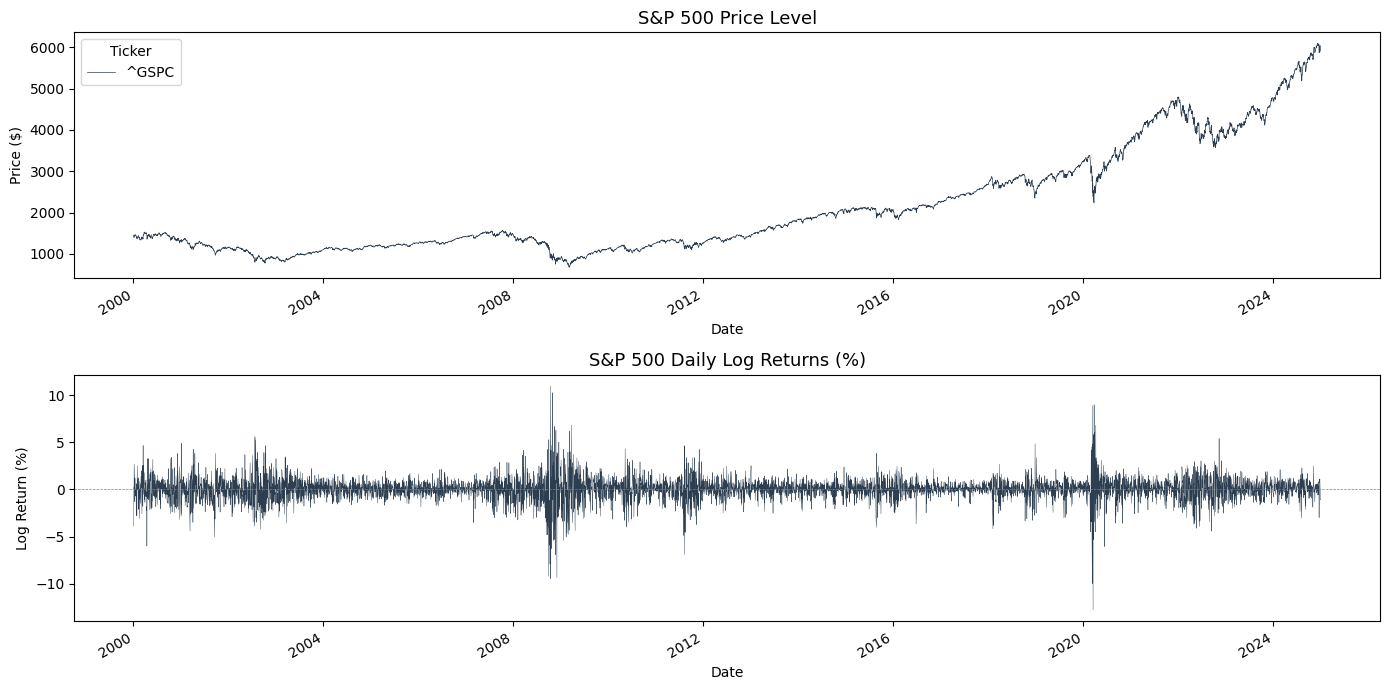

Observations: 6287
Mean return: 0.0223%
Std return: 1.2235%
Skewness: -0.3862
Kurtosis: 10.4040 (normal = 3)

Note the volatility clustering — large moves cluster together.


In [8]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 3a: Pull S&P 500 data and compute log returns
# -----------------------------------------------------------

# Download S&P 500 daily data
sp500 = yf.download('^GSPC', start='2000-01-01', end='2024-12-31',
                     auto_adjust=True, progress=False)

# Compute log returns (percentage)
sp500['log_return'] = np.log(sp500['Close'] / sp500['Close'].shift(1)) * 100
returns = sp500['log_return'].dropna()

# Visualize returns
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

sp500['Close'].plot(ax=axes[0], color='#2c3e50', linewidth=0.5)
axes[0].set_title('S&P 500 Price Level', fontsize=13)
axes[0].set_ylabel('Price ($)')

returns.plot(ax=axes[1], color='#2c3e50', linewidth=0.3)
axes[1].set_title('S&P 500 Daily Log Returns (%)', fontsize=13)
axes[1].set_ylabel('Log Return (%)')
axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

print(f'Observations: {len(returns)}')
print(f'Mean return: {returns.mean():.4f}%')
print(f'Std return: {returns.std():.4f}%')
print(f'Skewness: {returns.skew():.4f}')
print(f'Kurtosis: {returns.kurtosis():.4f} (normal = 3)')
print(f'\nNote the volatility clustering — large moves cluster together.')

In [9]:
# -----------------------------------------------------------
# YOUR TASK — Fit GARCH(1,1) to S&P 500 returns
# -----------------------------------------------------------

garch_spec = arch_model(
    returns,
    mean='Constant',       # constant mean model
    vol='GARCH',           # volatility model type
    p=1,                   # ARCH order (alpha term)
    q=1,                   # GARCH order (beta term)
    dist='normal',
)

garch_result = garch_spec.fit(disp='off')
print(garch_result.summary())

# Stationarity check
params = garch_result.params
alpha1 = params.get('alpha[1]', 0)
beta1 = params.get('beta[1]', 0)
persistence = alpha1 + beta1

print(f'\nalpha[1] = {alpha1:.4f}')
print(f'beta[1]  = {beta1:.4f}')
print(f'alpha + beta = {persistence:.4f} (must be < 1 for stationarity)')
assert persistence < 1, 'Volatility process is not stationary.'

print(f'Half-life of volatility shocks: {np.log(2) / (-np.log(persistence)):.1f} days')


                     Constant Mean - GARCH Model Results                      
Dep. Variable:             log_return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -8655.88
Distribution:                  Normal   AIC:                           17319.8
Method:            Maximum Likelihood   BIC:                           17346.8
                                        No. Observations:                 6287
Date:                Mon, Apr 20 2026   Df Residuals:                     6286
Time:                        01:03:09   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu             0.0615  1.029e-02      5.979  2.239e-09 [4.

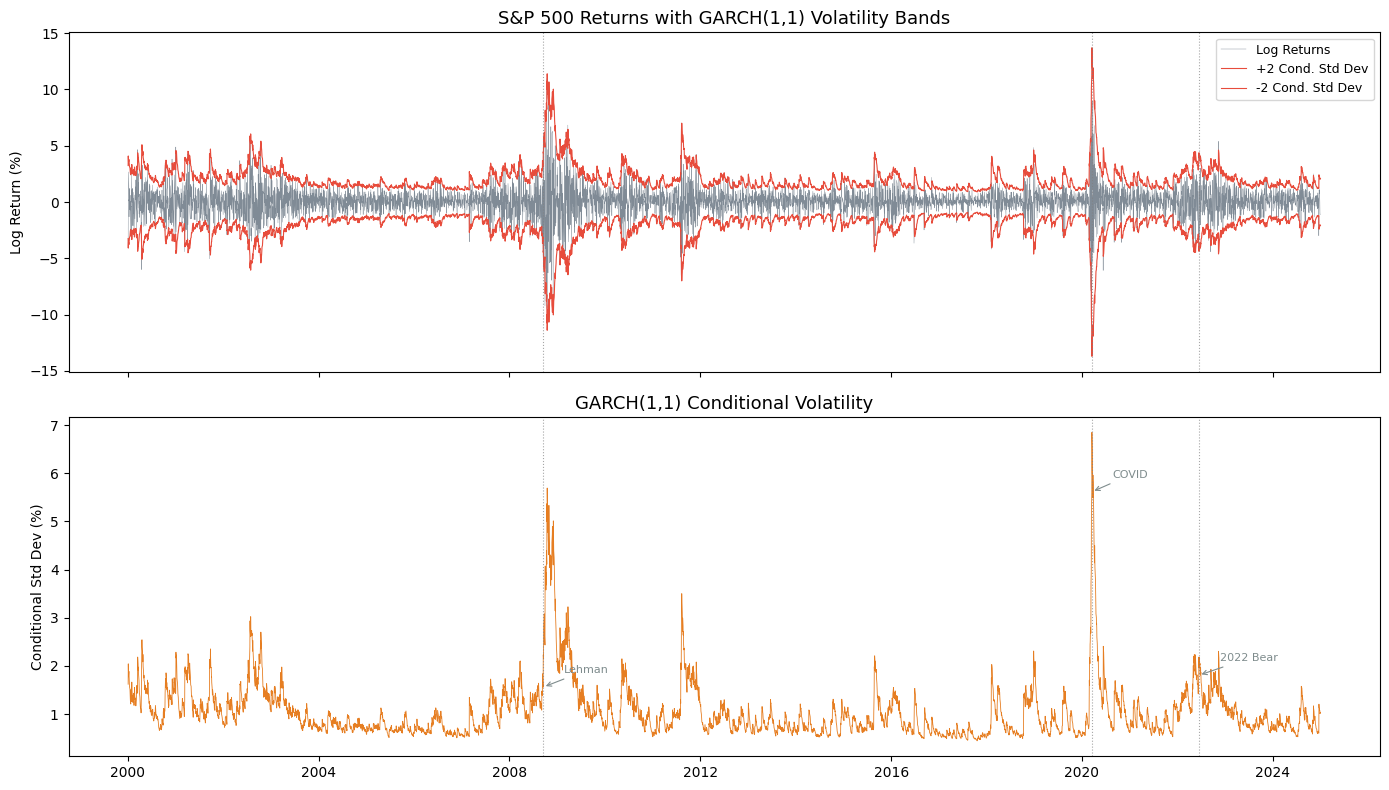

Unconditional (sample) volatility: 1.2235%
GARCH implied long-run volatility: 1.1628%
Max conditional volatility: 6.8504% on 2020-03-17


In [10]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 3c: Plot conditional volatility and annotate crises
# -----------------------------------------------------------

# Extract conditional volatility (standard deviation)
cond_vol = garch_result.conditional_volatility

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Panel 1: Returns with +/- 2*sigma bands
axes[0].plot(returns.index, returns.values, color='#2c3e50', linewidth=0.3,
             alpha=0.6, label='Log Returns')
axes[0].plot(cond_vol.index, 2 * cond_vol.values, color='#e74c3c',
             linewidth=0.8, label='+2 Cond. Std Dev')
axes[0].plot(cond_vol.index, -2 * cond_vol.values, color='#e74c3c',
             linewidth=0.8, label='-2 Cond. Std Dev')
axes[0].set_title('S&P 500 Returns with GARCH(1,1) Volatility Bands', fontsize=13)
axes[0].set_ylabel('Log Return (%)')
axes[0].legend(fontsize=9)

# Panel 2: Conditional volatility over time
axes[1].plot(cond_vol.index, cond_vol.values, color='#e67e22', linewidth=0.6)
axes[1].set_title('GARCH(1,1) Conditional Volatility', fontsize=13)
axes[1].set_ylabel('Conditional Std Dev (%)')

# Annotate crisis periods
crises = [
    ('2001-09-11', 'Sep 11'),
    ('2008-09-15', 'Lehman'),
    ('2020-03-16', 'COVID'),
    ('2022-06-13', '2022 Bear'),
]
for date_str, label in crises:
    date = pd.Timestamp(date_str)
    if date in cond_vol.index:
        for ax in axes:
            ax.axvline(date, color='gray', linestyle=':', linewidth=0.8, alpha=0.7)
        axes[1].annotate(label, xy=(date, cond_vol.loc[date]),
                        xytext=(15, 10), textcoords='offset points',
                        fontsize=8, color='#7f8c8d',
                        arrowprops=dict(arrowstyle='->', color='#7f8c8d', lw=0.8))

plt.tight_layout()
plt.show()

print(f'Unconditional (sample) volatility: {returns.std():.4f}%')
print(f'GARCH implied long-run volatility: {np.sqrt(garch_result.params["omega"] / (1 - alpha1 - beta1)):.4f}%')
print(f'Max conditional volatility: {cond_vol.max():.4f}% on {cond_vol.idxmax().date()}')

---

## Part 4: Module Output — `forecast_evaluation.py`

Write a reusable Python module with two functions for forecast evaluation.
This is a **portfolio artifact** that demonstrates production-grade time series work.

### Requirements

```python
# forecast_evaluation.py

def compute_mase(actual: np.ndarray, forecast: np.ndarray,
                 insample: np.ndarray, m: int = 1) -> float:
    """Compute Mean Absolute Scaled Error (MASE).
    
    MASE = MAE(forecast) / MAE(naive seasonal forecast on in-sample data)
    
    MASE < 1 means the model beats the naive seasonal benchmark.
    MASE > 1 means the naive benchmark is better.
    
    Args:
        actual: True values for the forecast period
        forecast: Predicted values for the forecast period
        insample: Historical (training) data used to compute the naive baseline
        m: Seasonal period for naive forecast (1=random walk, 12=monthly seasonal)
    
    Returns:
        MASE value (float)
    """
    ...

def backtest_expanding_window(
    series: pd.Series,
    model_fn,
    min_train: int = 120,
    horizon: int = 12,
    step: int = 12
) -> pd.DataFrame:
    """Expanding-window backtest for time series models.
    
    Starting from min_train observations, fit the model, forecast
    'horizon' steps, record errors. Then expand the training window
    by 'step' observations and repeat.
    
    Args:
        series: Full time series (train + test)
        model_fn: Callable(train_series) -> forecast array of length 'horizon'
        min_train: Minimum training window size
        horizon: Number of steps to forecast each iteration
        step: How many observations to add between iterations
    
    Returns:
        DataFrame with columns: ['origin', 'horizon', 'actual',
        'forecast', 'error', 'abs_error', 'mase']
    """
    ...
```

In [11]:
# -----------------------------------------------------------
# YOUR TASK — Forecast evaluation module
# -----------------------------------------------------------
# Canonical implementation lives in src/forecast_evaluation.py. We import it
# here so the notebook is self-contained but still exercises the module.

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd() / 'src'))

from forecast_evaluation import compute_mase, backtest_expanding_window

# Smoke test with the fitted SARIMA on CPI
actual = cpi.iloc[-24:].values
forecast_mean_arr = forecast_mean.values
insample = cpi.iloc[:-24].values

mase_vs_naive = compute_mase(actual, forecast_mean_arr, insample, m=1)
mase_vs_seasonal = compute_mase(actual, forecast_mean_arr, insample, m=12)
print(f'MASE vs random-walk baseline:  {mase_vs_naive:.3f}')
print(f'MASE vs seasonal-naive baseline: {mase_vs_seasonal:.3f}')
print('MASE < 1 means the SARIMA beats the corresponding naive benchmark.')

# Expanding-window backtest (use the SARIMA order we already selected)
def sarima_factory(train: pd.Series):
    return SARIMAX(train, order=best_order, seasonal_order=best_seasonal,
                   enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

backtest = backtest_expanding_window(cpi, sarima_factory,
                                     min_train=120, horizon=12, step=12,
                                     seasonal_m=12)
print('\nExpanding-window backtest:')
print(backtest.round(3))


MASE vs random-walk baseline:  29.427
MASE vs seasonal-naive baseline: 3.873
MASE < 1 means the SARIMA beats the corresponding naive benchmark.


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.f


Expanding-window backtest:
            train_size   rmse    mae   mase
train_end                                  
2009-12-01         120  3.556  3.113  0.615
2010-12-01         132  1.558  1.173  0.239
2011-12-01         144  0.769  0.679  0.134
2012-12-01         156  0.754  0.615  0.122
2013-12-01         168  1.424  1.061  0.216
2014-12-01         180  1.356  1.205  0.249
2015-12-01         192  1.154  0.824  0.181
2016-12-01         204  1.153  0.988  0.222
2017-12-01         216  1.468  1.446  0.322
2018-12-01         228  0.797  0.719  0.157
2019-12-01         240  2.679  2.305  0.504
2020-12-01         252  7.799  6.533  1.452
2021-12-01         264  8.841  8.187  1.683
2022-12-01         276  1.351  1.162  0.206
2023-12-01         288  4.336  3.481  0.589
2024-12-01         300    NaN    NaN    NaN


---

## Challenge: Block Bootstrap Forecast Intervals

Standard ARIMA confidence intervals assume normally distributed, i.i.d. residuals.
When residuals exhibit volatility clustering or heavy tails, these intervals
can be **too narrow**. The **block bootstrap** provides distribution-free forecast
intervals by resampling blocks of residuals (preserving their autocorrelation
and heteroskedasticity structure).

**Algorithm:**
1. Fit your SARIMA model and extract residuals
2. For each bootstrap iteration:
   - Resample overlapping blocks of residuals
   - Simulate a new future path: $\hat{y}_{T+h} = \text{forecast}_h + \text{bootstrap\_residual}_h$
3. Collect all bootstrap paths and compute percentile-based intervals

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


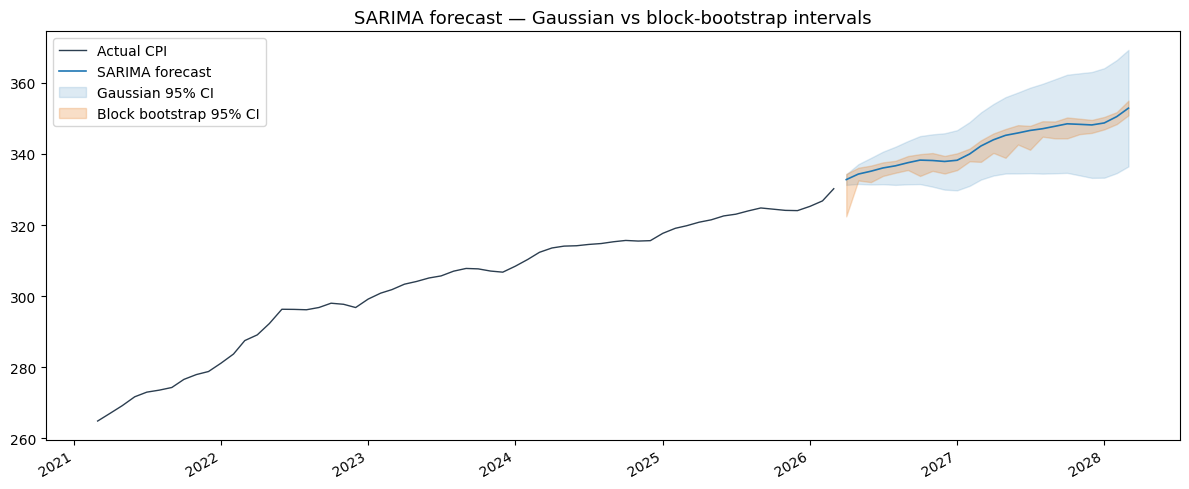

Mean Gaussian CI width:   19.479
Mean bootstrap CI width:  5.058


In [12]:
# -----------------------------------------------------------
# CHALLENGE — Block bootstrap forecast intervals
# -----------------------------------------------------------

def block_bootstrap_forecast(
    model_result,
    horizon: int = 24,
    n_bootstrap: int = 500,
    block_size: int = 6,
    alpha: float = 0.05,
    random_state: int = 42,
):
    """Generate block-bootstrap forecast intervals.

    Resample overlapping blocks of the fitted residuals, add them to the
    point forecast, and take pointwise percentiles across replications. The
    block structure preserves autocorrelation / volatility clustering that
    the Gaussian ARIMA intervals ignore.
    """
    rng = np.random.default_rng(random_state)

    point_forecast = model_result.get_forecast(steps=horizon)
    forecast_mean = point_forecast.predicted_mean.values
    residuals = np.asarray(model_result.resid)
    # statsmodels sometimes stores the first residual as the initial state —
    # drop the first one and any NaNs so we bootstrap clean in-sample residuals.
    residuals = residuals[~np.isnan(residuals)][1:]
    n_resid = len(residuals)
    if n_resid < block_size + 1:
        raise ValueError('Not enough residuals for the requested block size.')

    boot_paths = np.zeros((n_bootstrap, horizon))
    for b in range(n_bootstrap):
        boot_resid = np.empty(horizon)
        idx = 0
        while idx < horizon:
            start = int(rng.integers(0, n_resid - block_size + 1))
            take = min(block_size, horizon - idx)
            boot_resid[idx:idx + take] = residuals[start:start + take]
            idx += take
        boot_paths[b] = forecast_mean + boot_resid

    lower = np.quantile(boot_paths, alpha / 2, axis=0)
    upper = np.quantile(boot_paths, 1 - alpha / 2, axis=0)
    return {
        'mean': forecast_mean,
        'lower': lower,
        'upper': upper,
        'paths': boot_paths,
    }


bb = block_bootstrap_forecast(result, horizon=24, n_bootstrap=500, block_size=6)

# Compare to Gaussian CI from the fitted model
gaussian_ci = result.get_forecast(steps=24).conf_int(alpha=0.05)

fig, ax = plt.subplots(figsize=(12, 5))
future_index = pd.date_range(cpi.index[-1] + pd.offsets.MonthBegin(1), periods=24, freq='MS')

cpi[-60:].plot(ax=ax, color='#2c3e50', linewidth=1.0, label='Actual CPI')
ax.plot(future_index, bb['mean'], color='#1f77b4', linewidth=1.2, label='SARIMA forecast')
ax.fill_between(future_index, gaussian_ci.iloc[:, 0], gaussian_ci.iloc[:, 1],
                 alpha=0.15, color='#1f77b4', label='Gaussian 95% CI')
ax.fill_between(future_index, bb['lower'], bb['upper'],
                 alpha=0.25, color='#e67e22', label='Block bootstrap 95% CI')
ax.set_title('SARIMA forecast — Gaussian vs block-bootstrap intervals', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

print('Mean Gaussian CI width:   {:.3f}'.format(float((gaussian_ci.iloc[:, 1] - gaussian_ci.iloc[:, 0]).mean())))
print('Mean bootstrap CI width:  {:.3f}'.format(float((bb['upper'] - bb['lower']).mean())))


---

## Digital Portfolio: Institutional Signaling

### Generate Your Professional README

Copy and paste the prompt below into Claude or ChatGPT. **Do NOT ask the AI to write Python code — only documentation.**

```text
"I need help writing a project description for my data science lab.
**Important Rule:** Do NOT generate any Python code for me.

**What I did in this lab:**
* Diagnosed and fixed a broken ARIMA pipeline (d=0 on non-stationary CPI,
  missing seasonality, skipped Ljung-Box diagnostic)
* Corrected the pipeline to SARIMA with proper differencing and seasonal
  terms, verified clean residuals via Ljung-Box
* Fit GARCH(1,1) to S&P 500 daily returns to model conditional volatility
* Built a reusable forecast_evaluation.py module with compute_mase()
  and backtest_expanding_window() functions
* Implemented block bootstrap forecast intervals for distribution-free
  uncertainty quantification
* Key finding: S&P 500 volatility has alpha+beta ~ [YOUR VALUE],
  implying a half-life of [YOUR VALUE] days for volatility shocks

**Please write a README.md entry including:**
1. Project Title: Time Series Forecasting — ARIMA, GARCH & Bootstrap
2. Objective: A professional one-sentence summary
3. Methodology: Bullet points of technical steps
4. Key Findings: Summary of results
Make this sound like a professional tech economist wrote it."
```

### Push to GitHub

```bash
cd econ-lab-21-forecasting
git add notebooks/ src/ figures/ README.md
git commit -m "Lab 21: Time Series Forecasting — ARIMA, GARCH, Bootstrap"
git push origin main
```

Submit your GitHub repo link on Canvas.